In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

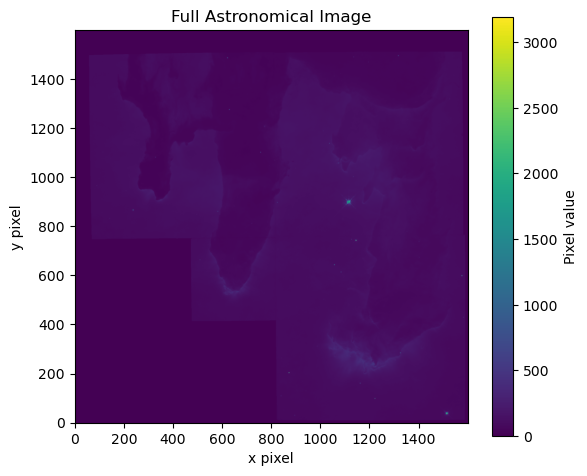

In [34]:
astro_image = np.loadtxt("astro_image.csv")

plt.figure(figsize=(6, 5))
plt.imshow(astro_image, origin="lower")
plt.colorbar(label="Pixel value")
plt.title("Full Astronomical Image")
plt.xlabel("x pixel")
plt.ylabel("y pixel")
plt.tight_layout()
plt.show()

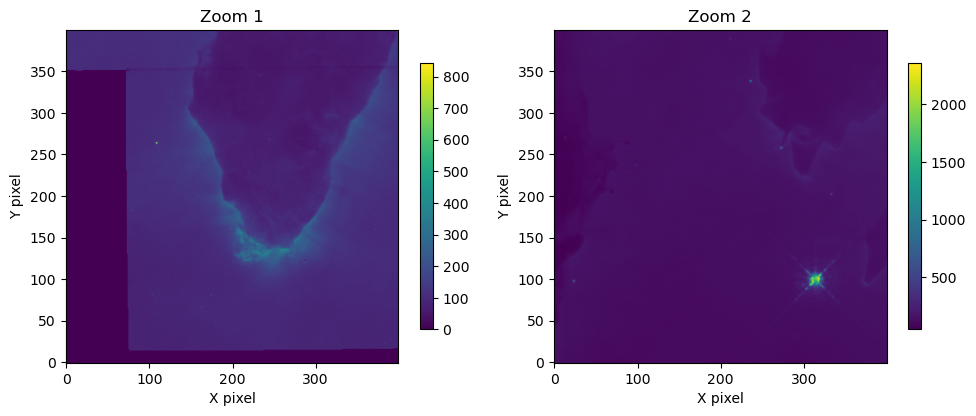

In [35]:
ny, nx = astro_image.shape

zoom1 = astro_image[ny//4:ny//2, nx//4:nx//2]
zoom2 = astro_image[ny//2:3*ny//4, nx//2:3*nx//4]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im1 = axes[0].imshow(zoom1, origin="lower")
axes[0].set_title("Zoom 1")
axes[0].set_xlabel("X pixel")
axes[0].set_ylabel("Y pixel")
plt.colorbar(im1, ax=axes[0], shrink=0.8)

im2 = axes[1].imshow(zoom2, origin="lower")
axes[1].set_title("Zoom 2")
axes[1].set_xlabel("X pixel")
axes[1].set_ylabel("Y pixel")
plt.colorbar(im2, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()

## pandas and ramen

In [36]:
ramen = pd.read_csv("ramen-ratings.csv")
print(ramen.head())


   Review #           Brand  \
0      2580       New Touch   
1      2579        Just Way   
2      2578          Nissin   
3      2577         Wei Lih   
4      2576  Ching's Secret   

                                             Variety Style Country Stars  \
0                          T's Restaurant Tantanmen    Cup   Japan  3.75   
1  Noodles Spicy Hot Sesame Spicy Hot Sesame Guan...  Pack  Taiwan     1   
2                      Cup Noodles Chicken Vegetable   Cup     USA  2.25   
3                      GGE Ramen Snack Tomato Flavor  Pack  Taiwan  2.75   
4                                    Singapore Curry  Pack   India  3.75   

  Top Ten  
0     NaN  
1     NaN  
2     NaN  
3     NaN  
4     NaN  


### what are the column names in this data set?:

In [37]:
ramen.columns

Index(['Review #', 'Brand', 'Variety', 'Style', 'Country', 'Stars', 'Top Ten'], dtype='object')

### what is the ramen style of the 27th entry? 

In [38]:
style_27 = ramen.iloc[26]["Style"]
print("The ramen style of the 27th entry is:", style_27)

The ramen style of the 27th entry is: Pack


### how many different ramen brands? 

In [39]:
num_brands = ramen["Brand"].nunique()
print("Number of different ramen brands:", num_brands)

Number of different ramen brands: 355


### sort the dataset by brand names

In [40]:
ramen_sorted_brand = ramen.sort_values(by="Brand")

# first few rows
ramen_sorted_brand.head()

,Review #,Brand,Variety,Style,Country,Stars,Top Ten
229,2351,1 To 3 Noodles,Chatpat Masala,Pack,India,4,NaN
456,2124,7 Select,Nissin Instant Noodles Tom Yum Seafood Creamy ...,Bowl,Thailand,3.5,NaN
463,2117,7 Select,Nissin Instant Noodles Shrimp Ma Nao Lui Suan ...,Bowl,Thailand,4,NaN
877,1703,7 Select/Nissin,Super Tom Yum Shrimp,Cup,Thailand,3.5,NaN
911,1669,A-One,Mi Ly Instant Noodles Mi Chay Vegetarian Flavor,Cup,Vietnam,1.25,NaN


### how many ramen brands are made in the USA

In [41]:
usa_brands = ramen.loc[ramen["Country"] == "USA", "Brand"].unique()
num_usa_brands = len(usa_brands)

print("Number of ramen brands made in the USA:", num_usa_brands)


Number of ramen brands made in the USA: 49


### how many ramen brands make pack style ramen

In [42]:
usa_pack = ramen[(ramen["Country"] == "USA") & (ramen["Style"] == "Pack")]
usa_pack_brands = usa_pack["Brand"].unique()
num_usa_pack_brands = len(usa_pack_brands)

print("Number of USA brands that make pack-style ramen:", num_usa_pack_brands)


Number of USA brands that make pack-style ramen: 27


### which brands have been in the top ten

In [43]:
top_ten_rows = ramen[ramen["Top Ten"].notna()]
top_ten_brands = top_ten_rows["Brand"].unique()

print("Brands that have been in the Top Ten:")
for b in top_ten_brands:
    print("-", b)


Brands that have been in the Top Ten:
- MAMA
- Prima Taste
- Prima
- Tseng Noodles
- Wugudaochang
- A-Sha Dry Noodle
- MyKuali
- CarJEN
- Maruchan
- Mamee
- Mama
- Sapporo Ichiban
- Nongshim
- Samyang Foods
- Paldo
- Indomie
- Koka
- Mi Sedaap
- Nissin
- Myojo
- Doll


## 3.3 linear regression


In [44]:
from astropy.table import Table

table = Table.read("global_CCl4_MM.dat", comment="#", format="ascii")

df_cc = table.to_pandas()

df_cc["date"] = pd.to_datetime(
    dict(year=df_cc["CCl4ottoyr"], month=df_cc["CCl4ottomon"], day=1)
)

df_cc = df_cc.rename(
    columns={
        "CCl4ottoGLm": "global mean concentration",
        "CCl4ottoGLsd": "global mean concentration sd",
    }
)

df_cc_small = df_cc[["date", "global mean concentration", "global mean concentration sd"]]
df_cc_small = df_cc_small.dropna()

df_cc_small.head()

,date,global mean concentration,global mean concentration sd
3,1996-04-01,104.144,0.155
4,1996-05-01,103.893,0.174
5,1996-06-01,104.207,0.191
6,1996-07-01,104.136,0.147
7,1996-08-01,103.836,0.161


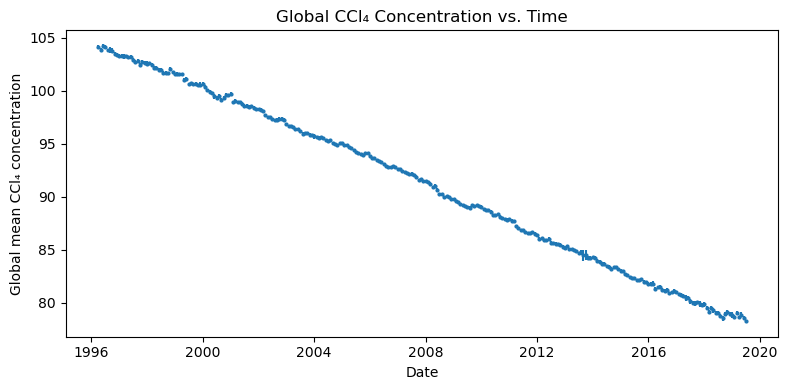

In [45]:
plt.figure(figsize=(8, 4))

plt.errorbar(
    df_cc_small["date"],
    df_cc_small["global mean concentration"],
    yerr=df_cc_small["global mean concentration sd"],
    fmt="o",
    markersize=2,
    linestyle="none",
)

plt.xlabel("Date")
plt.ylabel("Global mean CCl₄ concentration")
plt.title("Global CCl₄ Concentration vs. Time")
plt.tight_layout()
plt.show()

In [46]:
# 3.3.4 Fit a straight-line model y = m x + b

x = (df_cc_small["date"] - df_cc_small["date"].min()).dt.days.values
y = df_cc_small["global mean concentration"].values
sigma = df_cc_small["global mean concentration sd"].values

coeffs = np.polyfit(x, y, deg=1)
m, b = coeffs

print("Fitted slope m:", m)
print("Fitted intercept b:", b)

y_model = m * x + b

Fitted slope m: -0.003137731383493638
Fitted intercept b: 104.61571397712937


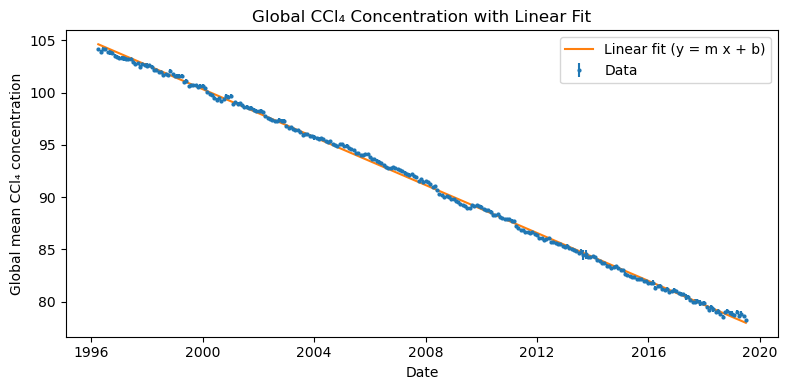

In [47]:
# Plot data with the fitted model

plt.figure(figsize=(8, 4))

# Data with error bars
plt.errorbar(
    df_cc_small["date"],
    df_cc_small["global mean concentration"],
    yerr=df_cc_small["global mean concentration sd"],
    fmt="o",
    markersize=2,
    linestyle="none",
    label="Data",
)

# Model (line)
plt.plot(df_cc_small["date"], y_model, label="Linear fit (y = m x + b)")

plt.xlabel("Date")
plt.ylabel("Global mean CCl₄ concentration")
plt.title("Global CCl₄ Concentration with Linear Fit")
plt.legend()
plt.tight_layout()
plt.show()

In [48]:
# compute the reduced chi-square

residuals = y_model - y
chi2 = np.sum((residuals / sigma) ** 2)

N = len(y)
chi2_reduced = chi2 / (N - 1)  

print("Chi-square:", chi2)
print("Reduced chi-square (chi^2 / (N - 1)):", chi2_reduced)


Chi-square: 1282.6221298839619
Reduced chi-square (chi^2 / (N - 1)): 4.597211935067963


### the straight line model matches the data well and no other shape would really work here

the chi squared value is about 4.6 which is greater than one but still fits well according to the graph.

## 4 OOP

In [50]:
class PlayingCharacter:
    def __init__(self, name, race, species, age):
        self.name = name
        self.race = race
        self.species = species
        self.age = age
        self.level = 1

    def roll_stats(self):
        import random
        self.strength = random.randint(1, 6)
        self.dexterity = random.randint(1, 6)
        self.intelligence = random.randint(1, 6)
        self.wisdom = random.randint(1, 6)
        self.charisma = random.randint(1, 6)
        self.constitution = random.randint(1, 6)
        stats = {}
        stats["Strength"] = self.strength
        stats["Dexterity"] = self.dexterity
        stats["Intelligence"] = self.intelligence
        stats["Wisdom"] = self.wisdom
        stats["Charisma"] = self.charisma
        stats["Constitution"] = self.constitution
        print(f"{self.name}'s rolled stats:", stats)

Connor = PlayingCharacter("Connor", "Human", "Warrior", 30)
Connor.roll_stats()



Connor's rolled stats: {'Strength': 3, 'Dexterity': 6, 'Intelligence': 1, 'Wisdom': 2, 'Charisma': 6, 'Constitution': 2}
